**VANILLA DQN IMPLEMENTATION FOR MOUNTAIN CAR V0 ENVIRONMENT**

In [36]:
import gymnasium as gym
import numpy as np
import random
from collections import deque
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
ENV_NAME = "MountainCar-v0"

def make_env(seed):
    env = gym.make(ENV_NAME)
    env.reset(seed=seed)

    # Override max episode steps to 2000 (IMPORTANT)
    env._max_episode_steps = 2000

    return env

In [ ]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, s, a, r, s_next, done):
        self.buffer.append((s, a, r, s_next, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, s_next, d = zip(*batch)

        return (
            torch.tensor(np.array(s), dtype=torch.float32, device=device),
            torch.tensor(a, dtype=torch.long, device=device),
            torch.tensor(r, dtype=torch.float32, device=device),
            torch.tensor(np.array(s_next), dtype=torch.float32, device=device),
            torch.tensor(d, dtype=torch.float32, device=device),
        )

    def __len__(self):
        return len(self.buffer)

In [ ]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        """
        Two hidden layers with 64 neurons each
        """
        self.net = nn.Sequential(                   
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )

        self.apply(self.init_weights)

    def init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
            nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

In [ ]:
HIDDEN_SIZE = 64
GAMMA = 0.99
LEARNING_RATE = 5e-4
BATCH_SIZE = 128
BUFFER_SIZE = 20000

EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY = 100000  

TARGET_UPDATE = 2000
NUM_EPISODES = 1000
MAX_STEPS = 2000
replay_factor = RHO = 1

In [ ]:
def select_action(state, q_net, epsilon, action_dim):
    if random.random() < epsilon:
        return random.randrange(action_dim)

    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        return q_net(state).argmax(dim=1).item()

In [ ]:
def train_dqn(seed=0):
    env = make_env(seed)

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    q_net = QNetwork(state_dim, action_dim).to(device)
    target_net = QNetwork(state_dim, action_dim).to(device)
    target_net.load_state_dict(q_net.state_dict())

    optimizer = optim.Adam(q_net.parameters(), lr=LEARNING_RATE)
    replay_buffer = ReplayBuffer(BUFFER_SIZE)

    epsilon = EPS_START
    epsilon_decay = (EPS_START - EPS_END) / EPS_DECAY

    rewards = []
    total_steps = 0
    # best_reward = -float("inf")
    for episode in range(NUM_EPISODES):
        state, _ = env.reset()
        episode_reward = 0

        for step in range(MAX_STEPS):
            total_steps += 1

            action = select_action(state, q_net, epsilon, action_dim)
            next_state, reward, terminated, truncated, _ = env.step(action)

            done = terminated or truncated

            replay_buffer.push(state, action, reward, next_state, done)
            state = next_state
            episode_reward += reward

            # Learning step
            # if len(replay_buffer) > BATCH_SIZE:
            #     s, a, r, s_next, d = replay_buffer.sample(BATCH_SIZE)

            #     q_values = q_net(s).gather(1, a.unsqueeze(1)).squeeze(1)

            #     with torch.no_grad():
            #         max_next_q = target_net(s_next).max(1)[0]
            #         target = r + GAMMA * max_next_q * (1 - d)

            #     loss = nn.MSELoss()(q_values, target)

            #     optimizer.zero_grad()
            #     loss.backward()
            #     optimizer.step()

            if len(replay_buffer) > BATCH_SIZE:
                for _ in range(replay_factor):   

                    s, a, r, s_next, d = replay_buffer.sample(BATCH_SIZE)

                    q_values = q_net(s).gather(1, a.unsqueeze(1)).squeeze(1)

                    with torch.no_grad():
                        max_next_q = target_net(s_next).max(1)[0]
                        target = r + GAMMA * max_next_q * (1 - d)

                    loss = nn.MSELoss()(q_values, target)

                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()
                    
            # Hard target update
            if total_steps % TARGET_UPDATE == 0:
                target_net.load_state_dict(q_net.state_dict())

            # Epsilon decay
            epsilon = max(EPS_END, epsilon - epsilon_decay)

            if done:
                break

        rewards.append(episode_reward)
        # if episode_reward > best_reward:
        #     best_reward = episode_reward
        #     torch.save(q_net.state_dict(), f"/kaggle/working/model_seed_{seed}.pth")

        if episode % 10 == 0:
            print(f"Episode {episode}, Reward: {episode_reward}, Epsilon: {epsilon:.3f}")

    env.close()
    return rewards

In [ ]:
LOG_JSONL = "results.jsonl"
open(LOG_JSONL, "w").close()

for seed in range(15):
    rewards = train_dqn(seed)

    record = {
        "label": "madhav_Q1",
        "seed": seed,

        "hyperparams": {
            "rho": RHO,
            "learning_rate": LEARNING_RATE,
            "gamma": GAMMA,
            "batch_size": BATCH_SIZE,
            "buffer_size": BUFFER_SIZE,
            "eps_start": EPS_START,
            "eps_end": EPS_END,
            "eps_decay": EPS_DECAY,
            "target_update": TARGET_UPDATE,
            "max_steps": MAX_STEPS,
            "num_episodes": NUM_EPISODES,
            "hidden_size": HIDDEN_SIZE
            "alpha": ALPHA,
            "beta_start": BETA_START,
            "beta_inc": BETA_INC
        },

        "rewards": rewards
    }

    with open(LOG_JSONL, "a") as f:
        f.write(json.dumps(record) + "\n")

**4 A : PLOTTING REWARDS VS EPISODES FOR DIFFERENT RHO VALUES**

In [37]:
def load_data(filepath):
    data = {}

    with open(filepath, "r") as f:
        for line in f:
            entry = json.loads(line)

            label = entry["label"]
            rho = entry["hyperparams"]["rho"]
            rewards = list(entry["rewards"])

            if label not in data:
                data[label] = {}

            if rho not in data[label]:
                data[label][rho] = []

            # append seed run
            data[label][rho].append(rewards)

    return data

In [38]:
data = load_data("results.jsonl")

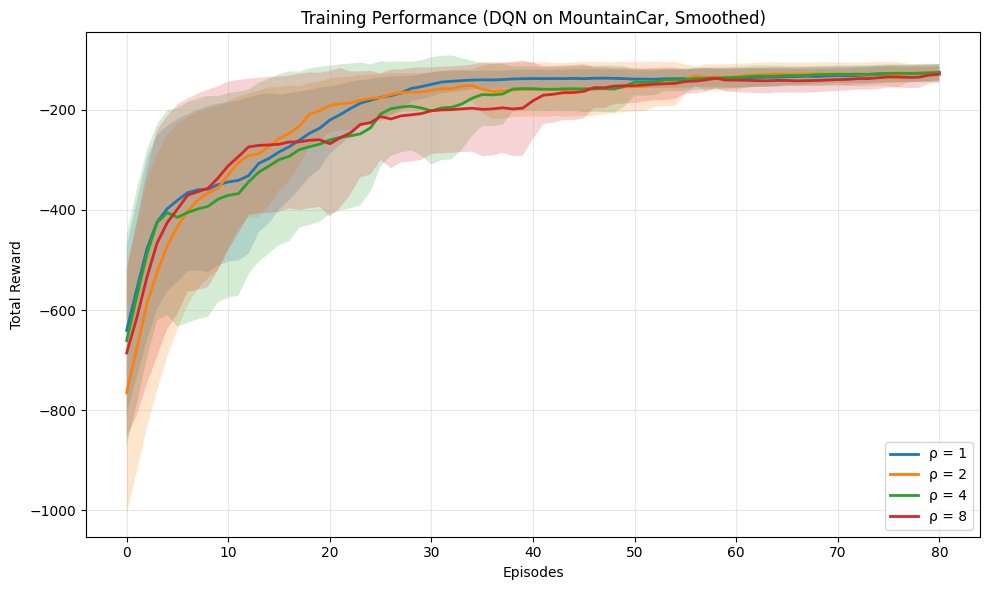

In [39]:
def moving_average(x, window=20):
    return np.convolve(x, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10, 6))

label = "soumya_Q4_a"

for rho in sorted(data[label].keys()):
    all_rewards = np.array(data[label][rho])
    mean_rewards = np.mean(all_rewards, axis=0)
    std = np.std(all_rewards, axis=0)
    n = all_rewards.shape[0]
    ci = 1.96 * std / np.sqrt(n)

    smooth_mean = moving_average(mean_rewards, window=20)
    smooth_ci = moving_average(ci, window=20)

    x = np.arange(len(smooth_mean))

    plt.plot(x, smooth_mean, label=f"ρ = {rho}", linewidth=2)
    plt.fill_between(
        x,
        smooth_mean - smooth_ci,
        smooth_mean + smooth_ci,
        alpha=0.2
    )

plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Training Performance (DQN on MountainCar, Smoothed)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

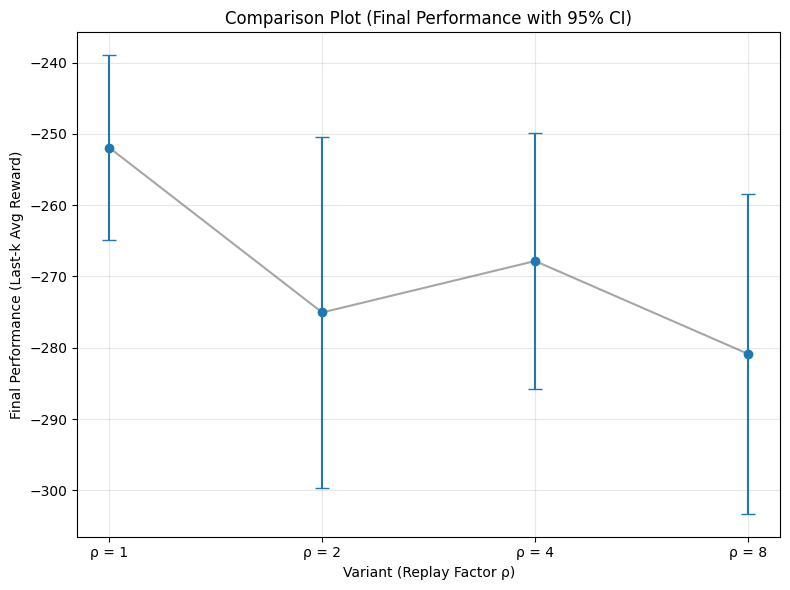

In [40]:
rhos = data[label].keys()

means = []
cis = []
k = 100   # last k episodes to average (tune: 50 / 100 / 200)

for rho in rhos:
    runs = data[label][rho] 
    final_scores = []

    for run in runs:
        final_scores.append(np.mean(run[-k:]))  # last-k average

    final_scores = np.array(final_scores)

    mean_val = np.mean(final_scores)
    std = np.std(final_scores)
    ci = 1.96 * std / np.sqrt(len(final_scores))

    means.append(mean_val)
    cis.append(ci)

plt.figure(figsize=(8,6))
x = np.arange(len(rhos))
plt.errorbar(
    x,
    means,
    yerr=cis,
    fmt='o',
    capsize=5
)
plt.plot(x, means, linestyle='-', color='gray', alpha=0.7)
plt.xticks(x, [f"ρ = {r}" for r in rhos])
plt.xlabel("Variant (Replay Factor ρ)")
plt.ylabel("Final Performance (Last-k Avg Reward)")
plt.title("Comparison Plot (Final Performance with 95% CI)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**4 B : DISTRIBUTION OF PERFORMANCE ACROSS DIFFERENT RHO VALUES**

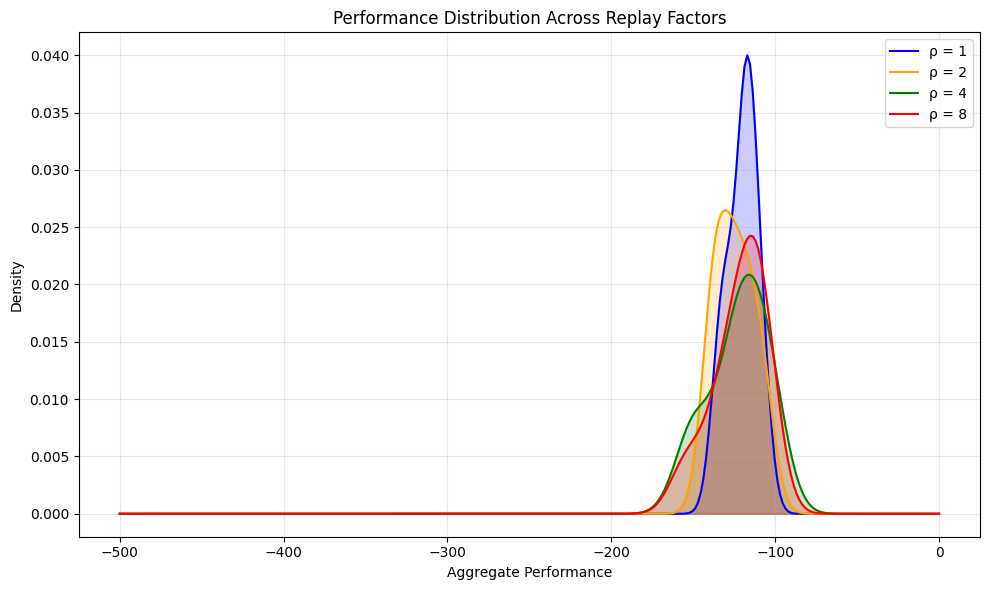

In [43]:
def compute_auc_per_run(data_rho):
    data_rho = np.array(data_rho)
    return np.mean(data_rho[:, -10:], axis=1)

label = "soumya_Q4_a"

auc_data = {}
for rho in data[label]:
    auc_data[rho] = compute_auc_per_run(data[label][rho])

plt.figure(figsize=(10,6))
colors = {1: 'blue', 2: 'orange', 4: 'green', 8: 'red'}

all_auc = np.concatenate(list(auc_data.values()))
x_vals = np.linspace(-500,0, 300)

for rho in auc_data:
    perf = auc_data[rho]
    kde = gaussian_kde(perf)

    plt.plot(x_vals, kde(x_vals), color=colors[rho], label=f"ρ = {rho}")
    plt.fill_between(x_vals, kde(x_vals), color=colors[rho], alpha=0.2)

plt.xlabel("Aggregate Performance")
plt.ylabel("Density")
plt.title("Performance Distribution Across Replay Factors")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**4 C : VARIABILITY IN PERFORMANCE (TOLERANCE INTERVALS)**

ρ = 1, k = 1.200
ρ = 2, k = 1.200
ρ = 4, k = 1.200
ρ = 8, k = 1.181


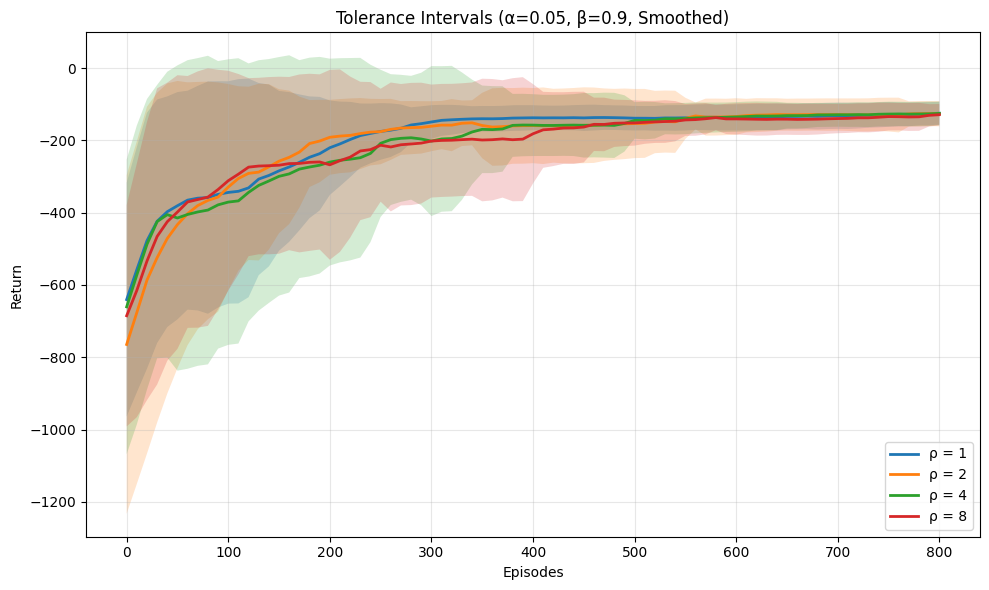

In [46]:
from scipy.stats import norm, chi2

label = "soumya_Q4_a"

def compute_k(n, alpha=0.05, beta=0.9):
    z = norm.ppf((1 + beta) / 2)          
    chi = chi2.ppf(1 - alpha, df=n - 1)   
    k = z * np.sqrt((n - 1) / chi)
    return k

def compute_tolerance_interval(data, alpha=0.05, beta=0.9):
    n = data.shape[0]
    k = compute_k(n, alpha, beta)

    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0)

    lower = mean - k * std
    upper = mean + k * std

    return mean, lower, upper, k

plt.figure(figsize=(10,6))

window = 20 

for rho in data[label]:
    arr = np.array(data[label][rho])  
    mean, lower, upper, k = compute_tolerance_interval(arr)
    print(f"ρ = {rho}, k = {k:.3f}")  

    mean_s = np.convolve(mean, np.ones(window)/window, mode='valid')
    lower_s = np.convolve(lower, np.ones(window)/window, mode='valid')
    upper_s = np.convolve(upper, np.ones(window)/window, mode='valid')

    x = np.arange(len(mean_s)) * 10  

    plt.plot(x, mean_s, label=f"ρ = {rho}", linewidth=2)
    plt.fill_between(x, lower_s, upper_s, alpha=0.2)

plt.xlabel("Episodes")
plt.ylabel("Return")
plt.title("Tolerance Intervals (α=0.05, β=0.9, Smoothed)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**ENVIRONMENT VISUALISATION USING STORED MODEL WEIGHTS**

In [ ]:
env = gym.make("MountainCar-v0")

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
q_net = QNetwork(state_dim, action_dim).to(device)

q_net.load_state_dict(torch.load("model_seed_0.pth", map_location=device))
q_net.eval()

In [ ]:
import imageio

def record_video(model, filename="mountaincar.mp4", max_steps=2000):

    env = gym.make("MountainCar-v0", render_mode="rgb_array")
    frames = []
    state, _ = env.reset()

    for _ in range(max_steps):

        # --- Select action (greedy) ---
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)

        with torch.no_grad():
            q_values = model(state_tensor)

        action = torch.argmax(q_values).item()
        next_state, reward, terminated, truncated, _ = env.step(action)

        frame = env.render()
        frames.append(frame)

        state = next_state
        if terminated or truncated:
            break

    env.close()

    imageio.mimsave(filename, frames, fps=30)
    print(f"Saved video: {filename}")

In [ ]:
record_video(q_net, filename="mountaincar.mp4")